# BEE 4750 Homework 2: Systems Modeling and Simulation

**Name**:

**ID**:

> **Due Date**
>
> Thursday, 09/25/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to draw a systems diagram and identify the type
    of a feedback.
-   Problem 2 asks you to model contaminant concentrations in a river
    and use simulation to compare the concentrations to a regulatory
    standard.
-   Problem 3 asks you to explore the implications of an ice-albedo
    feedback in the Earth’s climate system by understanding the
    equilibria of the modeled system and their stabilities.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\Donny\OneDrive\Post-Grad\Courses\BEE 5750\Homework 2\hw2-donny-1`
   Installed JpegTurbo_jll ─────────────── v3.1.3+0
   Installed InvertedIndices ───────────── v1.3.1
   Installed SentinelArrays ────────────── v1.4.8
   Installed WorkerUtilities ───────────── v1.6.1
   Installed InlineStrings ─────────────── v1.4.5
   Installed Roots ─────────────────────── v2.2.10
   Installed Accessors ─────────────────── v0.1.42
   Installed DataFrames ────────────────── v1.8.0
   Installed WeakRefStrings ────────────── v1.4.2
   Installed TableTraits ───────────────── v1.0.1
   Installed ConstructionBase ──────────── v1.6.0
   Installed DataValueInterfaces ───────── v1.0.0
   Installed PooledArrays ──────────────── v1.4.3
   Installed Ghostscript_jll ───────────── v9.55.1+0
   Installed CompositionsBase ──────────── v0.1.2
   Installed PrettyTables ──────────────── v3.0.8
   Installed CommonSolve ───────────────── v0.2.4
   Installed InverseFunctions ──────────── 

In [9]:
using Plots
using LaTeXStrings
using CSV
using DataFrames
using Roots

## Problems (Total: 30 Points)

### Problem 1 (5 points)

Draw a systems diagram for the relationship between global mean
temperature, atmospheric CO<sub>2</sub> concentrations, and ocean
CO<sub>2</sub> concentrations. What are the signs of the interactions
between these components and why? What does this suggest about the
overall feedback between temperature and the ocean carbon cycle?

> **Tip**
>
> Think about Henry’s law for CO<sub>2</sub>.

### Problem 2 (15 points)

A river which flows at 10 km/d is receiving discharges of wastewater
contaminated with CRUD from two sources which are 15 km apart, as shown
in the Figure below. CRUD decays exponentially in the river at a rate of
0.36 $\mathrm{d}^{-1}$ and is deposited by the atmosphere along the
river at a rate of 54 kg/km/d. 

<figure>
<img src="attachment:figures/river_diagram.png"
alt="Schematic of the river system in Problem 2" />
<figcaption aria-hidden="true">Schematic of the river system in Problem
2</figcaption>
</figure>

#### Problem 2.1

Draw a systems diagram with the relevant control volume(s) denoted and
any relevant in/out-flows between these boxes. How did you decide how
many boxes were needed?

#### Problem 2.2

Develop a model for the concentration of CRUD downriver by formulating
and solving the appropriate differential equation(s) analytically.

> **Tip**
>
> Formulate your model in terms of distance downriver, rather than
> leaving it in terms of time from discharge.

#### Problem 2.3

Determine if the system in compliance with a regulatory limit of
$2.3\ \text{kg}/(1000 \text{m}^3)$. You can do this analytically or
computationally.

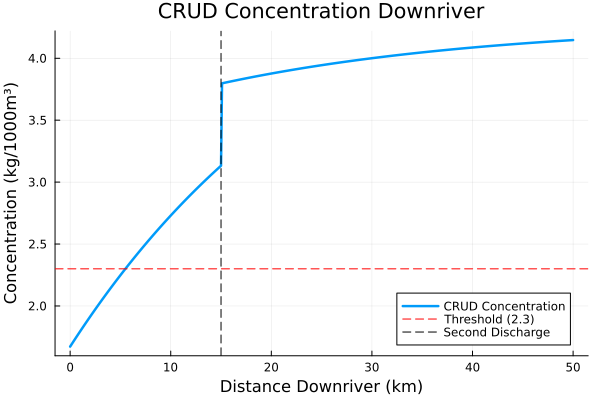

In [14]:
function concentration_segment1(x)
    return 5.172 - 3.500 * exp(-0.036 * x)
end

function concentration_segment2(x)
    return 4.286 - 0.490 * exp(-0.036 * (x - 15))
end

function get_concentration(x)
    if 0 <= x <= 15
        return concentration_segment1(x)
    elseif x > 15
        return concentration_segment2(x)
    else
        return NaN
    end
end

function plot_concentration_profile()
    # Define the distance ranges, concentrations, and threshold
    x_values = 0:0.1:50 # from 0 to 50 km, with a step of 0.1 km
    y_values = get_concentration.(x_values)
    threshold = 2.3

    # Plotting the concentration profile
    p = plot(x_values, y_values,
        label="CRUD Concentration",
        linewidth=2.5,
        title="CRUD Concentration Downriver",
        xlabel="Distance Downriver (km)",
        ylabel="Concentration (kg/1000m³)",
        legend=:bottomright
    )
    hline!(p, [threshold],
        linestyle=:dash,
        color=:red,
        label="Threshold (2.3)"
    )
    vline!(p, [15],
        linestyle=:dash,
        color=:black,
        label="Second Discharge"
    )
    display(p)
end
plot_concentration_profile()



Based on the plotting above, it can be inferred that after around 5 kilos from the starting point (x=0), the concentration of CRUD will always surpass the threshold (2.3 kg/1000m^3). This shows that the decay rate of the CRUD cannot offset the amount and/or concentration of the discharges.

Thus, either the volume or the concentration of the CRUD need to be adjusted.

### Problem 3 (10 points)

In class, we discussed the ice-albedo feedback and its possible
influence on melting the hypothesized [“Snowball
Earth”](https://en.wikipedia.org/wiki/Snowball_Earth). In this problem,
we’ll introduce a simple model of the Earth’s energy balance with
includes this feedback and examine the stability of the climate.

This simple model of the energy balance (averaged over the entire
planet) is:

<span id="eq-climate">$$
\underbrace{C\frac{dT}{dt}}_{\text{change in heat}} = \underbrace{\frac{(1-\alpha)S}{4}}_{\text{incoming radiation}} - \underbrace{(A - BT)}_{\text{outgoing radiation}} + \underbrace{a\ln \left(\frac{[CO_2]}{[CO_2]_{PI}}\right)}_{\text{greenhouse effect}},
 \qquad(1)$$</span>

where:

-   $T$ is the Earth’s global mean temperature (in $^\circ\text{C}$);
-   $C$ is the heat capacity of the atmosphere and shallow ocean, taken
    to be $51\ \text{J}/\text{m}^2/^\circ\text{C}$;
-   $\alpha$ is the planetary albedo, or the fraction of incoming
    radiation reflected by the Earth, which has a present-day value of
    approximately 0.3;
-   $S$ is the solar constant, or the amount of solar radiation received
    by the Earth averaged over area, which has a present-day value of
    $1368\ \text{W}/\text{m}^2$ but during the Neoproteorozoic Era had a
    value of $1272\ \text{W}/\text{m}^2$ (this is divided by four
    because the Earth is a sphere but $S$ is the radiation captured by a
    disc with radius equal to that of the Earth);
-   $A$ and $B$ are coefficients from the linearization of outgoing
    radiation physics, and have corresponding values
    $B=-1.3\ \text{W}/\text{m}^2/^\circ\text{C}$ (estimated from a
    number of lines of evidence about the sensitivity of outgoing
    radiation to temperature; this is negative due to a sign convention
    about the direction of incoming vs. outgoing radiation) and
    $A=221.2\ \text{W}/\text{m}^2$ (estimated by assuming the
    pre-industrial temperature of $14^\circ\text{C}$ was stable without
    anthropogenic greenhouse gas emissions).

We will ignore the greenhouse effect term as we are considering the
Earth system well before humans were around.

#### Problem 3.1

Discretize the climate model
(<a href="#eq-climate" class="quarto-xref">Equation 1</a>) using forward
Euler integration and a time step of $\Delta t = 1$ yr.

#### Problem 3.2

Rather than assuming a constant value for the albedo $\alpha$, we will
represent the ice-albedo feedback by letting $\alpha$ depend on $T$:

$$\alpha(T) = 
    \begin{cases} 
        \alpha_i & \quad \text{if } T \leq -10^\circ \text{C} \\
        \alpha_i + (\alpha_0 - \alpha_i)((T+10) / 20) & \quad \text{if } -10^\circ \text{C} \leq T \leq 10^\circ \text{C} \\
        \alpha_0 & \quad \text{if } T \geq 10^\circ \text{C}.
    \end{cases}$$

Let $\alpha_i = 0.5$ and $\alpha_0 = 0.3$. Simulate the simple climate
model using the Neoprotereozoic value of $S$ with temperature-varying
albedo for initial values of $T$ spanning
$-60^\circ\text{C} \leq T_0 \leq 30^\circ\text{C}$ over a period of 200
years. Plot the temperature trajectories. How many equilibria are there
and what are their stabilities?

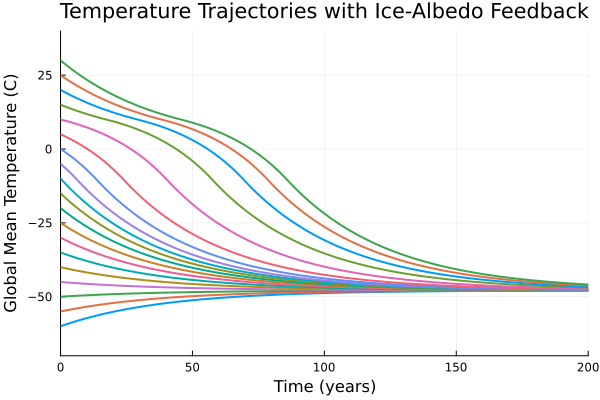

Simulation complete. Displaying plot.


In [ ]:
# Physical constants
const C = 51.0         # Heat capacity (J/m²/°C) - Scaled for a time step in years
const S = 1272.0       # Solar constant for Neoproterozoic (W/m²)
const A = 221.2        # Outgoing radiation coefficient (W/m²)
const B = -1.3         # Outgoing radiation coefficient (W/m²/°C)
const a_i = 0.5        
const a_0 = 0.3        

# Simulation parameters
const dt_years = 1.0                              # Time step in years
const simulation_years = 200                      # Total simulation time
const num_steps = Int(simulation_years / dt_years)
const initial_temps = -60.0:5.0:30.0              # Range of initial T₀ (°C)


# Albedo function
function albedo(T::Float64)
    if T <= -10.0
        return a_i
    elseif -10.0 < T <= 10.0
        return a_i + (a_0 - a_i) * ((T + 10.0) / 20.0)
    else # T > 10.0
        return a_0
    end
end


# Main simulation
p = plot(
    title="Temperature Trajectories with Ice-Albedo Feedback",
    xlabel="Time (years)",
    ylabel="Global Mean Temperature (C)",
    legend=false,
    xlims=(0, simulation_years),
    ylims=(-70, 40)
)

for T0 in initial_temps
    temperatures = zeros(Float64, num_steps + 1)
    temperatures[1] = T0

    for i in 1:num_steps
        T_current = temperatures[i]
        
        incoming_rad = (1 - albedo(T_current)) * S / 4.0
        outgoing_rad = A - B * T_current
        net_radiation = incoming_rad - outgoing_rad
        T_next = T_current + (dt_years / C) * net_radiation
        temperatures[i+1] = T_next
    end
    
    time_axis = 0:dt_years:simulation_years
    plot!(p, time_axis, temperatures, lw=2)
end

println("Simulation complete. Displaying plot.")
display(p)

#### Problem 3.3

One might hypothesize that one cause for the transition from Snowball
Earth (the stable frozen equilibrium from Problem 3.2) was an increasing
amount of incoming solar radiation (as expressed by an increase in $S$).
Examine this hypothesis using our simple model. Is this factor enough to
cause the planet to warm to the pre-industrial temperature of
$14^\circ\text{C}$?

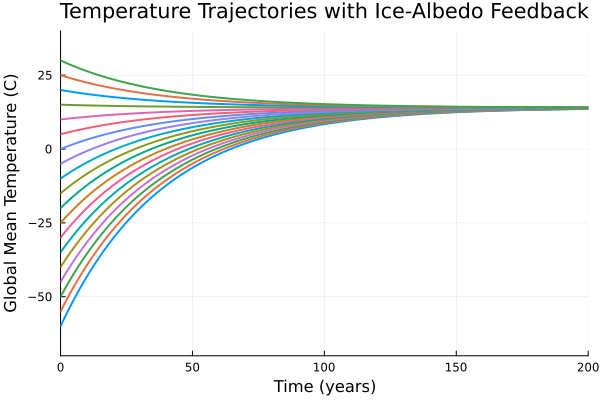

Simulation complete. Displaying plot.


In [ ]:
# Physical constants
const C = 51.0         # Heat capacity (J/m²/°C) - Scaled for a time step in years
const S = 1368.0       # Solar constant for modern era (W/m²)
const A = 221.2        # Outgoing radiation coefficient (W/m²)
const B = -1.3         # Outgoing radiation coefficient (W/m²/°C)     
const a_0 = 0.3        

# Simulation parameters
const dt_years = 1.0                              # Time step in years
const simulation_years = 200                      # Total simulation time
const num_steps = Int(simulation_years / dt_years)
const initial_temps = -60.0:5.0:30.0              # Range of initial T₀ (°C)


# Albedo function
function albedo(T::Float64)
       return a_0
end


# Main simulation
p = plot(
    title="Temperature Trajectories with Ice-Albedo Feedback",
    xlabel="Time (years)",
    ylabel="Global Mean Temperature (C)",
    legend=false,
    xlims=(0, simulation_years),
    ylims=(-70, 40)
)

for T0 in initial_temps
    temperatures = zeros(Float64, num_steps + 1)
    temperatures[1] = T0

    for i in 1:num_steps
        T_current = temperatures[i]
        
        incoming_rad = (1 - albedo(T_current)) * S / 4.0
        outgoing_rad = A - B * T_current
        net_radiation = incoming_rad - outgoing_rad
        T_next = T_current + (dt_years / C) * net_radiation
        temperatures[i+1] = T_next
    end
    
    time_axis = 0:dt_years:simulation_years
    plot!(p, time_axis, temperatures, lw=2)
end

println("Simulation complete. Displaying plot.")
display(p)

According to the model being used, an increase in the solar radiation is capable of moving the earth from the Snowball Earth state. The graph above illustrates when the solar radiation (S) is 1368 W/m^2 and the alpha (a_0) = 0.3 (less reflective surface). Across all ranges of initial temperature assumed (-60C<T<30C), all approach the equilibrium of approximately 14 C.

## References

LLM was used in this homework, specifically for problem 2.3 and 3.2
1. For problem 2.3, LLM was used to generate code for the plotting into the graph section. After the code is generated, user double check and debug the code if necessary
2. For problem 3.2, LLM was used to assist in building the loop for function and incorporating initial temperature limits. The code is then studied to learn the loop for structure and being debugged if necessary